# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari kaggel https://www.kaggle.com/datasets/ardikasatria/datasettanamanpadisumatera


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from joblib import dump

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.DataFrame(pd.read_csv("drive/MyDrive/padi/Data_Tanaman_Padi_Sumatera_version_1.csv"))

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [8]:
df.shape

(224, 7)

In [9]:
df.head()

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27
3,Aceh,1996,1419128.0,348223.0,1557.0,83.00,26.08
4,Aceh,1997,1368074.0,337561.0,1339.0,82.46,26.31


In [10]:
df.describe()

,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
count,224.000000,2.240000e+02,224.000000,224.000000,224.000000,224.000000
mean,2006.500000,1.679701e+06,374349.966920,2452.490759,80.948705,26.801964
std,8.095838,1.161387e+06,232751.161987,1031.972625,4.878680,1.197041
min,1993.000000,4.293800e+04,63142.040000,222.500000,54.200000,22.190000
25%,1999.750000,5.488570e+05,146919.500000,1703.525000,78.975000,26.177500
50%,2006.500000,1.667773e+06,373551.500000,2315.700000,82.375000,26.730000
75%,2013.250000,2.436851e+06,514570.250000,3039.700000,84.000000,27.200000
max,2020.000000,4.881089e+06,872737.000000,5522.000000,90.600000,29.850000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    object 
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.4+ KB


In [12]:
df.isna().sum()

,0
Provinsi,0
Tahun,0
Produksi,0
Luas Panen,0
Curah hujan,0
Kelembapan,0
Suhu rata-rata,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
pd.pivot_table(df,index=['Provinsi'],values=['Produksi'], aggfunc=np.mean)

/tmp/ipykernel_1336/784897022.py:1: FutureWarning: The provided callable <function mean at 0x7b06fb5758a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.pivot_table(df,index=['Provinsi'],values=['Produksi'], aggfunc=np.mean)


,Produksi
Provinsi,
Aceh,1.618737e+06
Bengkulu,4.449648e+05
Jambi,5.528638e+05
Lampung,2.444068e+06
Riau,4.074645e+05
Sumatera Barat,1.990396e+06
Sumatera Selatan,2.648643e+06
Sumatera Utara,3.330471e+06


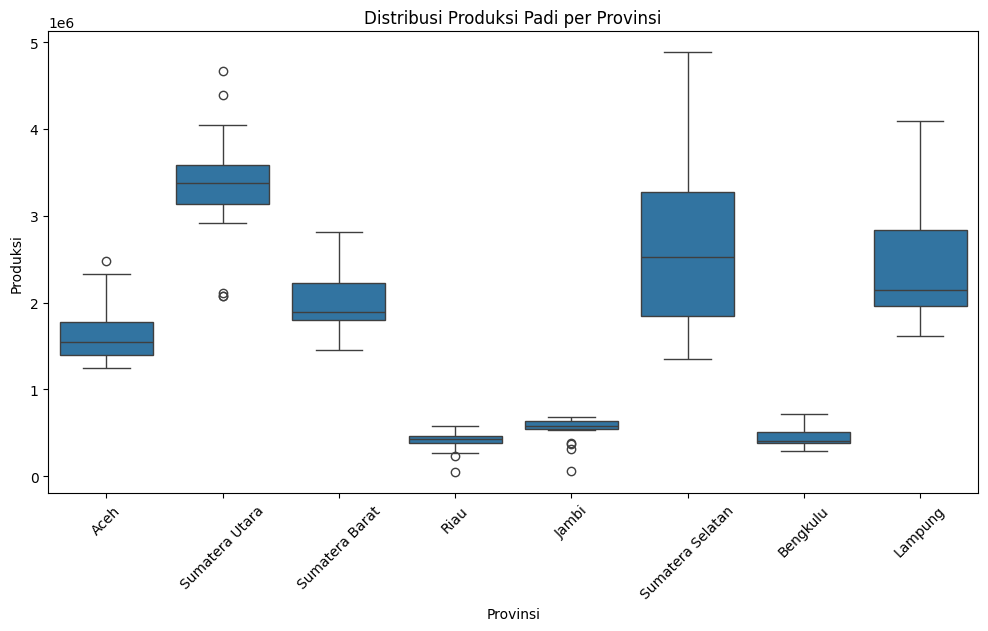

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Provinsi', y='Produksi', data=df)
plt.title('Distribusi Produksi Padi per Provinsi')
plt.xticks(rotation=45)
plt.show()

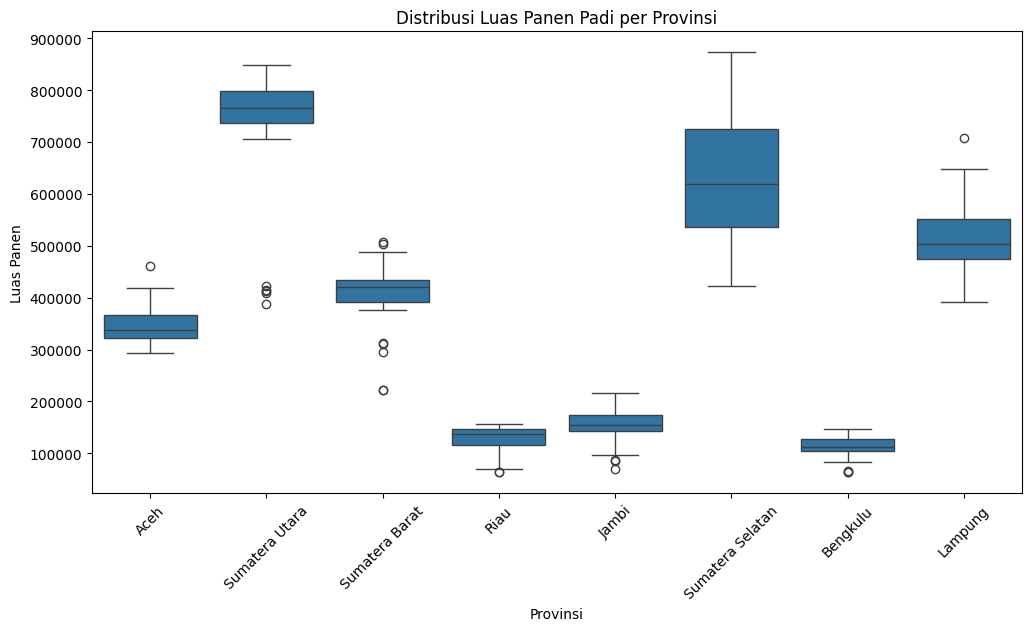

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Provinsi', y='Luas Panen', data=df)
plt.title('Distribusi Luas Panen Padi per Provinsi')
plt.xticks(rotation=45)
plt.show()

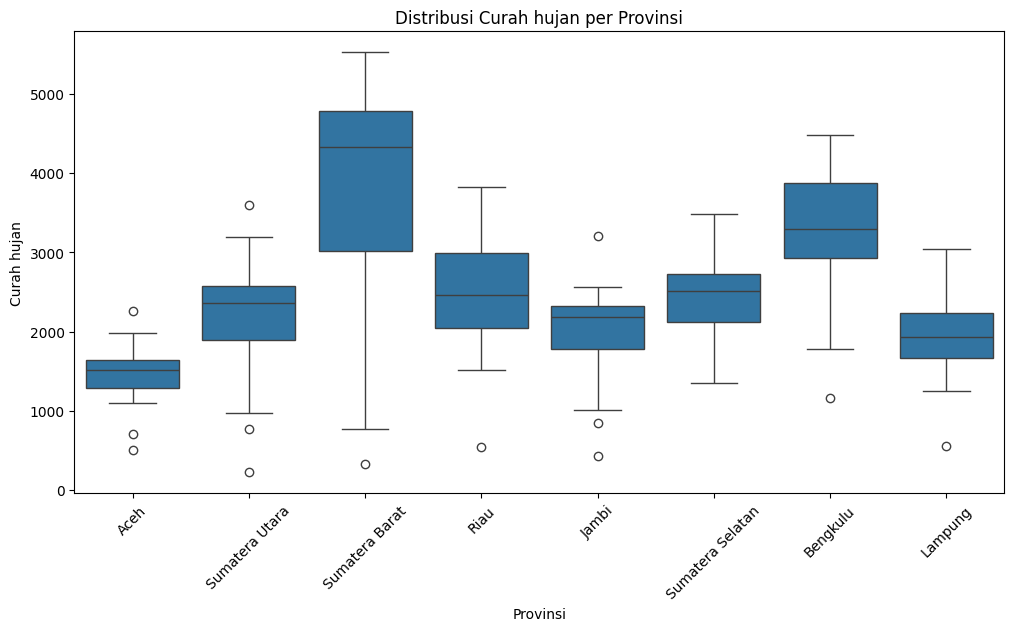

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Provinsi', y='Curah hujan', data=df)
plt.title('Distribusi Curah hujan per Provinsi')
plt.xticks(rotation=45)
plt.show()

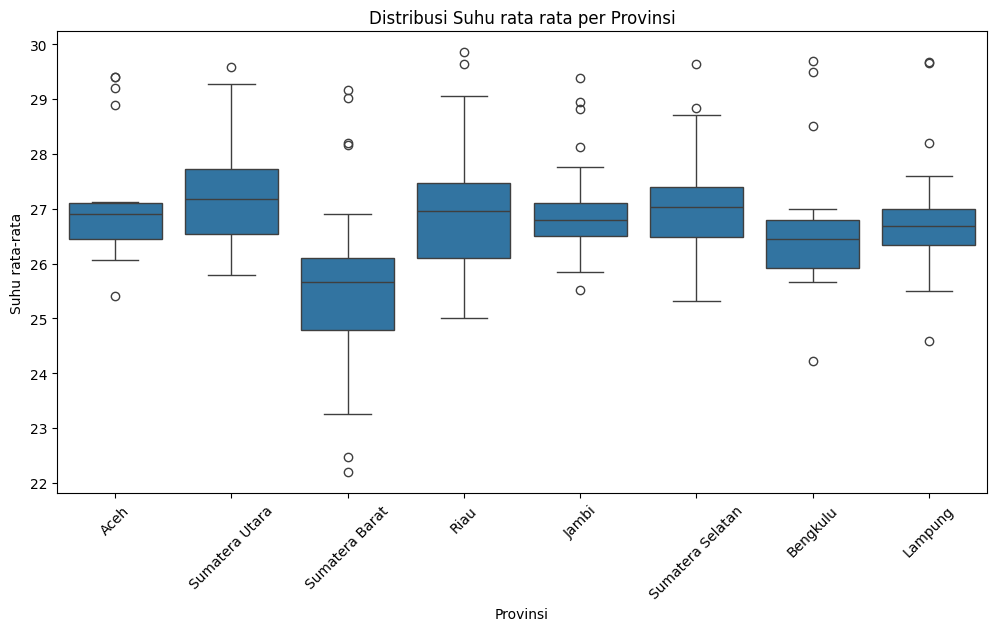

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Provinsi', y='Suhu rata-rata', data=df)
plt.title('Distribusi Suhu rata rata per Provinsi')
plt.xticks(rotation=45)
plt.show()

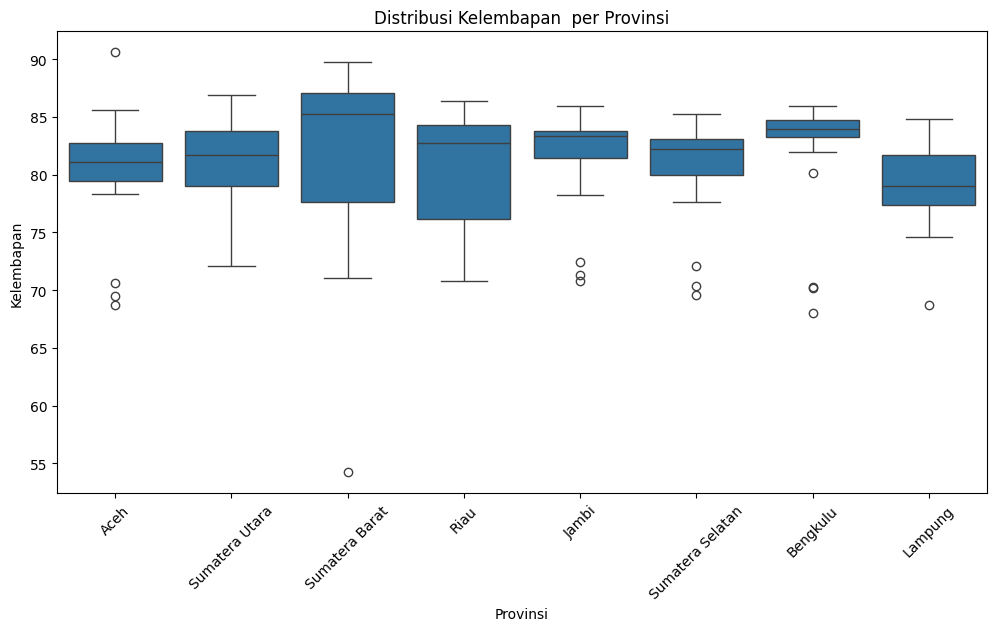

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Provinsi', y='Kelembapan', data=df)
plt.title('Distribusi Kelembapan  per Provinsi')
plt.xticks(rotation=45)
plt.show()

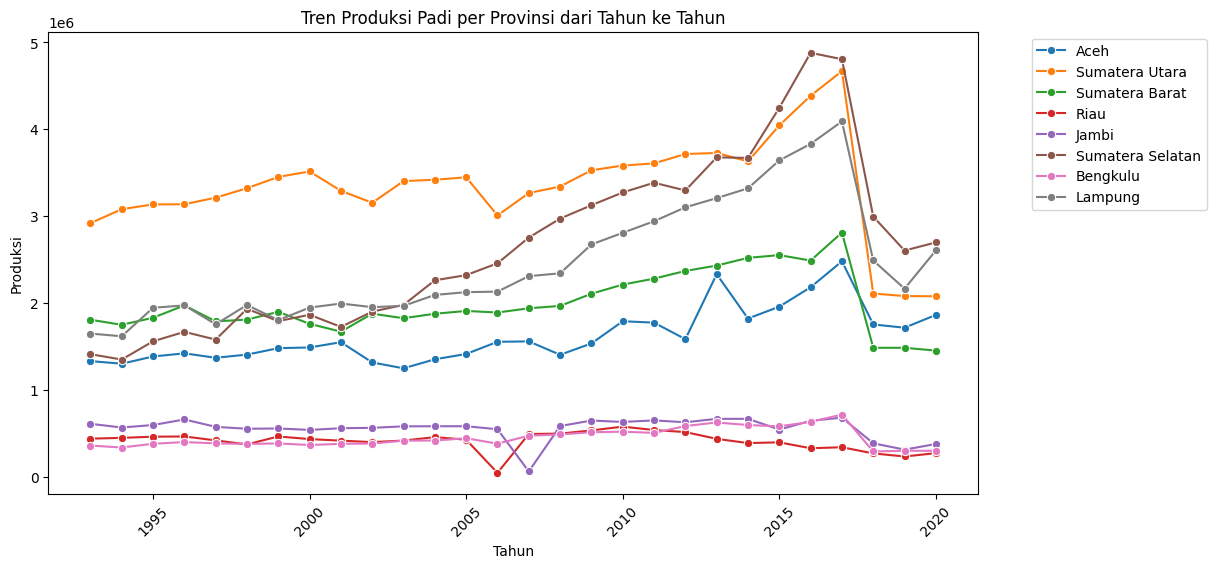

In [20]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Tahun', y='Produksi', hue='Provinsi', data=df, marker='o')
plt.title('Tren Produksi Padi per Provinsi dari Tahun ke Tahun')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_1336/3567675998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_produksi.index, y=total_produksi.values, palette='viridis')


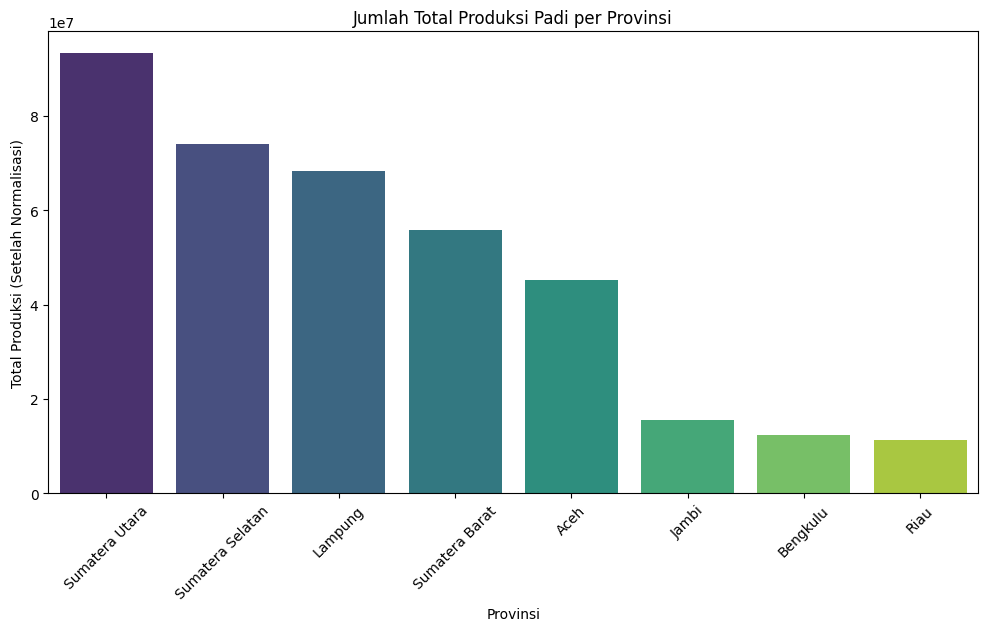

In [21]:
total_produksi = df.groupby('Provinsi')['Produksi'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=total_produksi.index, y=total_produksi.values, palette='viridis')
plt.title('Jumlah Total Produksi Padi per Provinsi')
plt.xlabel('Provinsi')
plt.ylabel('Total Produksi (Setelah Normalisasi)')
plt.xticks(rotation=45)
plt.show()

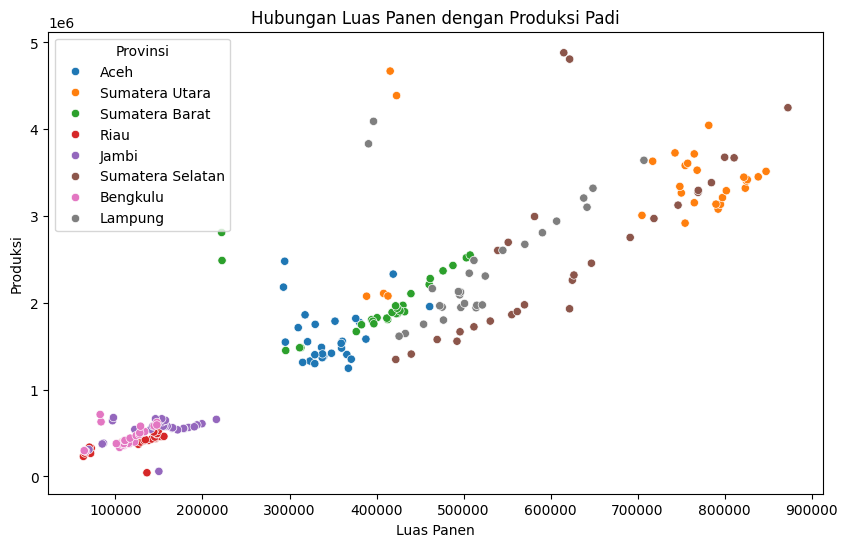

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Luas Panen', y='Produksi', hue='Provinsi', data=df)
plt.title('Hubungan Luas Panen dengan Produksi Padi')
plt.show()

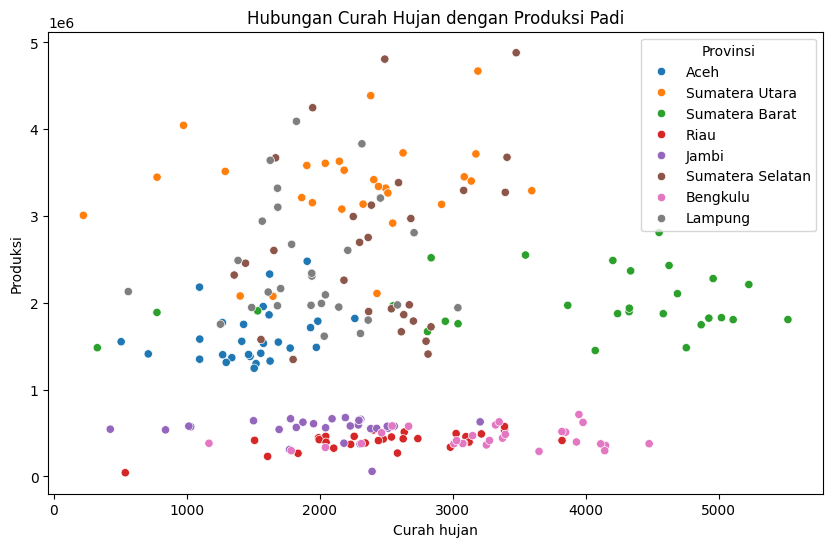

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Curah hujan', y='Produksi', hue='Provinsi', data=df)
plt.title('Hubungan Curah Hujan dengan Produksi Padi')
plt.show()

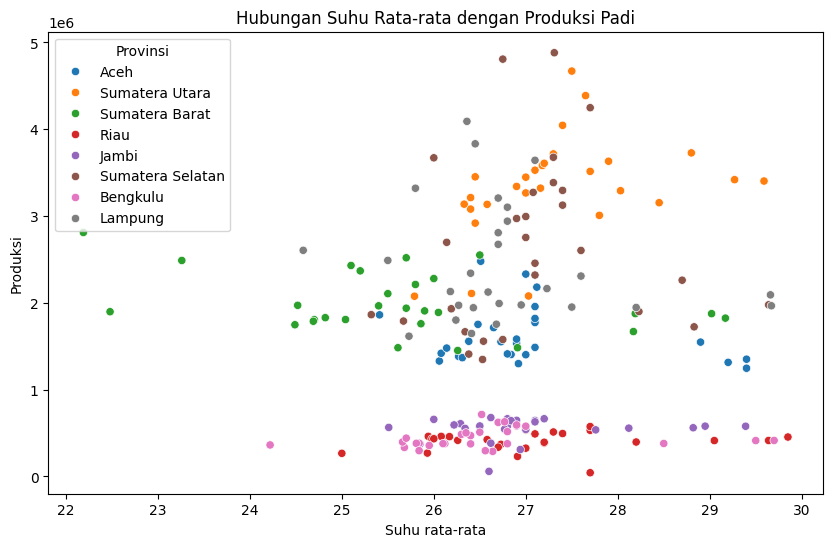

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Suhu rata-rata', y='Produksi', hue='Provinsi', data=df)
plt.title('Hubungan Suhu Rata-rata dengan Produksi Padi')
plt.show()

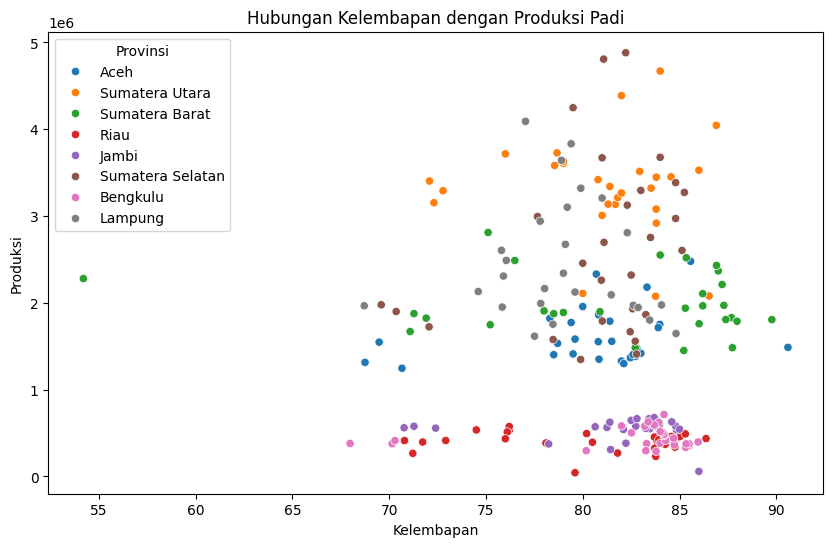

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Kelembapan', y='Produksi', hue='Provinsi', data=df)
plt.title('Hubungan Kelembapan dengan Produksi Padi')
plt.show()

/tmp/ipykernel_1336/3467097368.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Tahun', y='Produksi', data=df, estimator='sum', ci=None, marker='o')


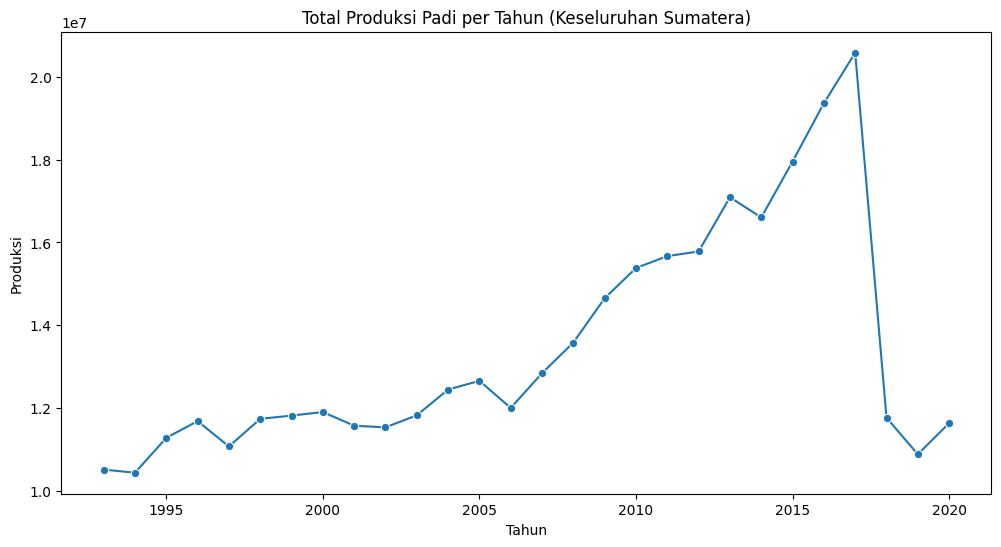

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Tahun', y='Produksi', data=df, estimator='sum', ci=None, marker='o')
plt.title('Total Produksi Padi per Tahun (Keseluruhan Sumatera)')
plt.show()

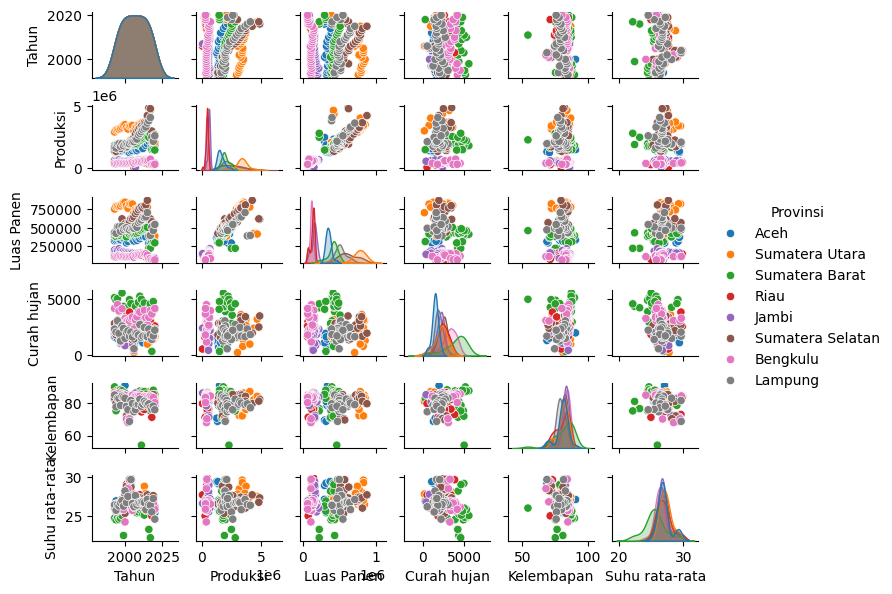

In [27]:
sns.pairplot(df, hue='Provinsi', height=1, aspect=1.2)
plt.show()

In [28]:
label_encoder = LabelEncoder()
df['Provinsi'] = label_encoder.fit_transform(df['Provinsi'])

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [29]:
label_encoder = LabelEncoder()
df['Provinsi'] = label_encoder.fit_transform(df['Provinsi'])

In [30]:
inverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}
inverse_label_mapping

{0: np.int64(0),
 1: np.int64(1),
 2: np.int64(2),
 3: np.int64(3),
 4: np.int64(4),
 5: np.int64(5),
 6: np.int64(6),
 7: np.int64(7)}

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    int64  
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 12.4 KB


In [32]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Memfilter data lalu menghapus outlier
df_filtered = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186 entries, 0 to 222
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        186 non-null    int64  
 1   Tahun           186 non-null    int64  
 2   Produksi        186 non-null    float64
 3   Luas Panen      186 non-null    float64
 4   Curah hujan     186 non-null    float64
 5   Kelembapan      186 non-null    float64
 6   Suhu rata-rata  186 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 11.6 KB


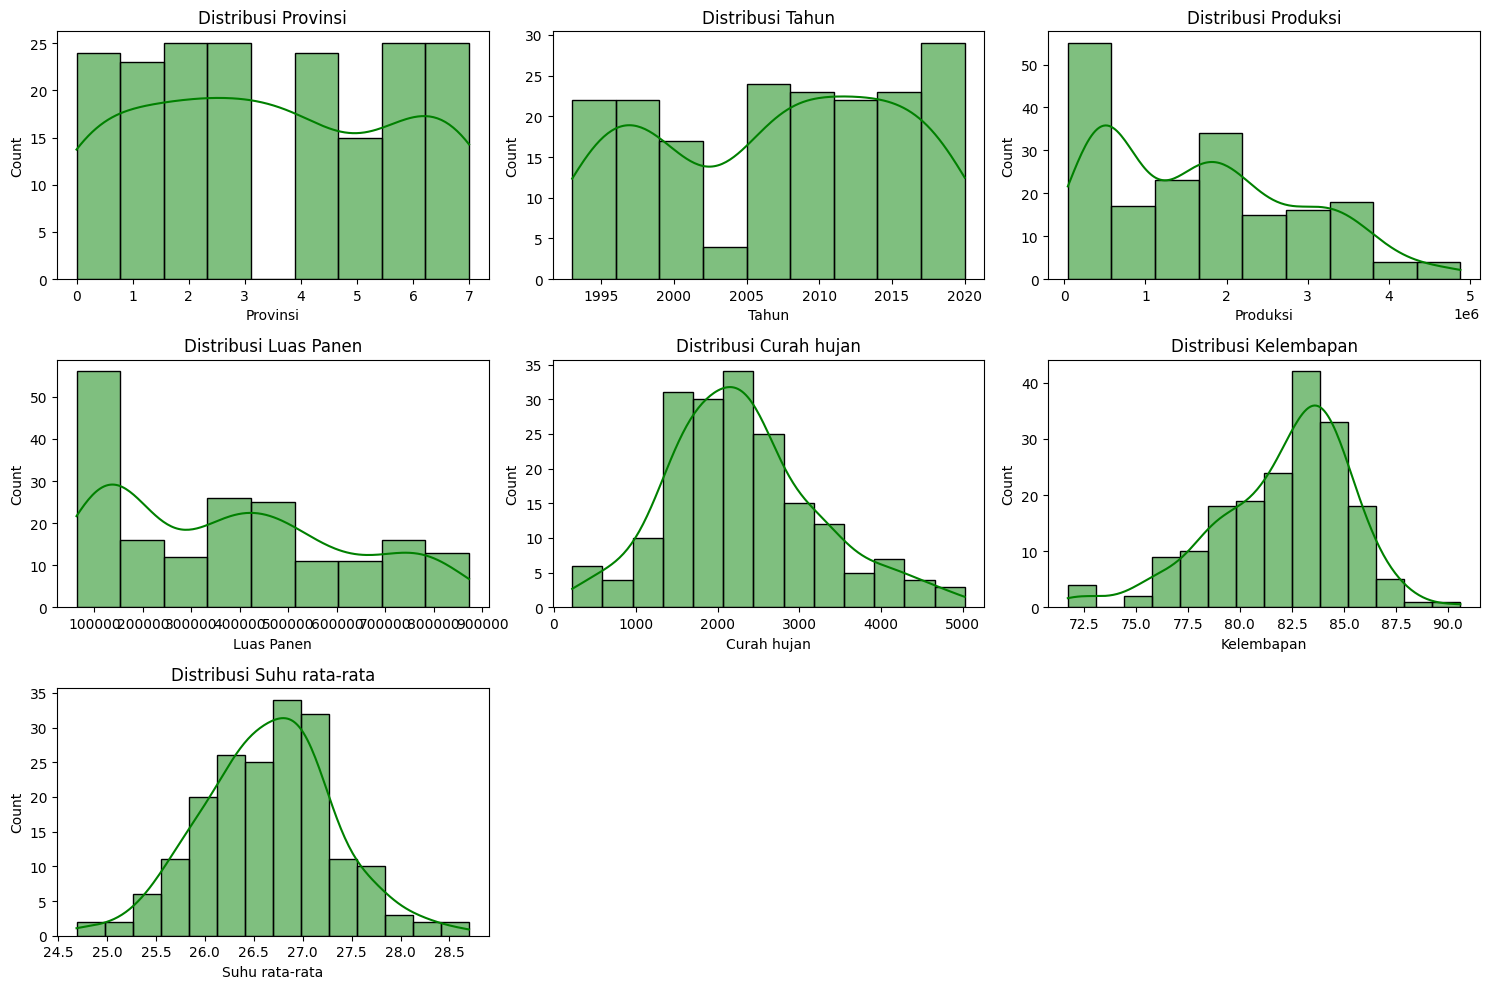

In [33]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df_filtered.select_dtypes(include=['float64', 'int64']).columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_filtered[column], kde=True, color='green')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

In [34]:
scaler = MinMaxScaler()
df_normalized = df_filtered.copy()
numeric_columns = df_normalized.select_dtypes(include=['int64', 'float64']).columns.drop('Provinsi')
df_normalized[numeric_columns] = scaler.fit_transform(df_normalized[numeric_columns])

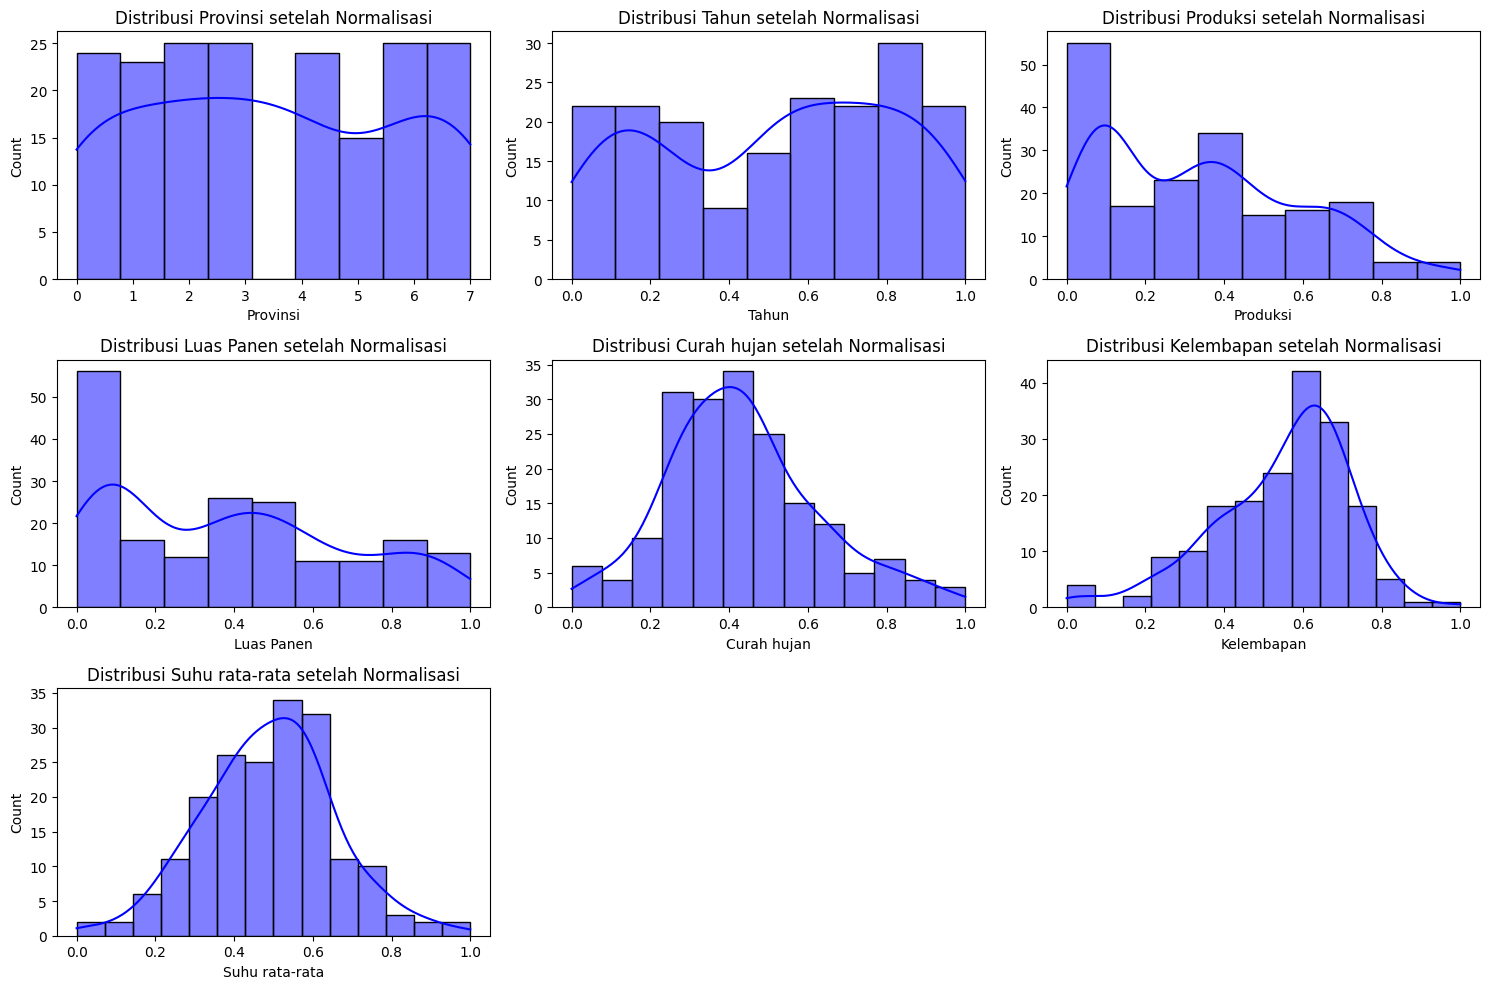

In [35]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df_normalized.select_dtypes(include=['float64', 'int64']).columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_normalized[column], kde=True, color='blue')
    plt.title(f'Distribusi {column} setelah Normalisasi')

plt.tight_layout()
plt.show()

In [36]:
df_normalized.head()

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,0,0.000000,0.265928,0.321700,0.292635,0.544250,0.341646
1,0,0.037037,0.259761,0.328435,0.270549,0.550609,0.556110
2,0,0.074074,0.276958,0.341048,0.261173,0.582406,0.394015
3,0,0.111111,0.284445,0.352128,0.278050,0.597244,0.346633
4,0,0.148148,0.273893,0.338958,0.232628,0.568627,0.403990


In [37]:
df_normalized.describe()

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
count,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000
mean,3.462366,0.518917,0.342836,0.389456,0.434394,0.548256,0.487598
std,2.327551,0.310041,0.248434,0.295001,0.193331,0.171235,0.169159
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.250000,0.222222,0.103982,0.102869,0.299240,0.438262,0.382793
50%,3.000000,0.555556,0.321638,0.370756,0.423680,0.583996,0.501247
75%,6.000000,0.777778,0.510213,0.575739,0.533826,0.655140,0.600998
max,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [38]:
df_normalized.to_csv('padi_clean.csv', index=False)

In [39]:
# Menyimpan scaler dan label encoder
dump(scaler, 'scaler.joblib')
dump(label_encoder, 'label_encoder.joblib')

['label_encoder.joblib']